# 🫀 ECG ResNet1D — **v2 ÓPTIMO** (base 48, señal 1250 · CPU · modelo independiente)
## TFM · Módulo ECG · Universidad de Salamanca

---

Versión óptima del módulo de electrocardiograma: **ResNet-1D más profunda** (2 bloques por etapa,
base 48) sobre señal de 1250 puntos, con **aumento rico**, tuning por **Optuna** y **ensemble por
bagging** de los modelos de cada fold.

## 🔄 Adaptación a las conclusiones del EDA

| Cambio | Detalle | Origen (recuadro naranja) |
|---|---|---|
| **Etiquetado FINAL** | `POS=(==1)` · `NEG=(==0)|(NaN→0)` · **−1 ENMASCARADO** (U-Ignore). **Se elimina** la derivación de negativos desde *No Finding* (`DERIVE_NEGATIVES_FROM_EXCLUSIVITY=False`), que introducía **sesgo de espectro**. | §3 Definición del negativo |
| **Métrica primaria = AUC-PR** | `macro_AP_path` gobierna **Optuna**, el early-stopping, el K-fold y la selección; **AUC-ROC pasa a secundaria**; **IC bootstrap** de AP y AUC (por etiqueta y macro). | §3 Métrica · §1 IC |
| **Puntos de operación** | Tres umbrales fijados en VAL: F1, **cribado (Se≥0,90)** y **confirmación (Sp≥0,90)**, con **Se/Sp/VPP/VPN** y recuento de FN/FP. | §11 Puntos de operación |
| **Calibración verificada** | **Brier** antes/después de la isotónica + curva de fiabilidad. | §11 Calibración |
| **Pre-registro** | La regla de decisión se congela en JSON **antes** de tocar test. | §11 Protocolo |
| **Equidad y robustez** | Estratificación por sexo, etnia, ingreso y **proyección AP/PA**. | §2/§9 · Anexo CXR |

### Decisiones específicas de esta modalidad
- **Señal intacta**: llega normalizada a **[−1, 1]**, 12 derivaciones × 5000 muestras (~10 s @500 Hz);
  se remuestrea a 1250 puntos pero **no se re-normaliza por derivación**, para conservar la amplitud
  relativa entre ellas (las precordiales V2–V4 son legítimamente mayores). → Anexo EDA
- **`cxr_view` NUNCA como predictor**: es un proxy de gravedad (la placa AP se hace al paciente
  encamado). Se usa **solo para estratificar** resultados.
- **B5 y B7 no aplican**: no hay variables tabulares cuya importancia medir ni patrón de *missingness*
  que vigilar. Esa información MNAR entra por el módulo tabular y se propaga en la fusión. → §6

> **Aviso:** con el nuevo etiquetado y la nueva métrica, los resultados **no son comparables** con los
> de la ejecución previa. Hay que reentrenar y volver a documentar.



In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch",
                    "--index-url","https://download.pytorch.org/whl/cpu","-q"], check=True)
for pkg in ["optuna","scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.isotonic import IsotonicRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_CORES=4; torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"]=str(N_CORES); os.environ["MKL_NUM_THREADS"]=str(N_CORES)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} · {DEVICE} · hilos {torch.get_num_threads()}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.8.0+cpu · cpu · hilos 4


In [3]:
# CELDA 3 · RUTAS Y CONSTANTES (v3.1)
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
NPY=BASE/"data_npy"
ECG_TRAIN_NPY,ECG_VAL_NPY,ECG_TEST_NPY=NPY/"train"/"ecg_train.npy",NPY/"val"/"ecg_val.npy",NPY/"test"/"ecg_test.npy"
HADM_TRAIN_NPY,HADM_VAL_NPY,HADM_TEST_NPY=NPY/"train"/"hadm_id_train.npy",NPY/"val"/"hadm_id_val.npy",NPY/"test"/"hadm_id_test.npy"
OUTPUT_DIR=Path("C:/TFM/1.Opción - Symile Mimic/tfm_multimodal_clinico/salidas/02_ecg/v2"); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
PREP_DIR=OUTPUT_DIR/"prep"; PREP_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
N_LEADS,ECG_RAW_LEN=12,5000
ECG_LEN=1250          # v3.1: mayor resolución temporal (~125 Hz)
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=False   # <- etiquetado FINAL: no derivar de No Finding (sesgo de espectro)

GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
RACE_ONEHOT=5
META_DIM=1+1+RACE_ONEHOT+len(ADMISSION_MAP)+len(ADM_LOC_MAP)+1   # 16

FAST_MODE=False
OPTUNA_TRIALS,TUNE_SUBSAMPLE,TUNE_EPOCHS,TUNE_PATIENCE=10,0.6,6,3
K_FOLDS,FINAL_EPOCHS,FINAL_PATIENCE=3,24,5
BATCH=64; BASE_WIDTH=48; BLOCKS_PER_STAGE=2     # v3.1: más ancho y profundo
if FAST_MODE:
    OPTUNA_TRIALS,TUNE_EPOCHS,K_FOLDS,FINAL_EPOCHS=3,3,2,6
print(f"v3.1 · ECG {N_LEADS}x{ECG_RAW_LEN}->{ECG_LEN} · base={BASE_WIDTH} bloques/etapa={BLOCKS_PER_STAGE} · trials={OPTUNA_TRIALS} K={K_FOLDS} ep={FINAL_EPOCHS}")




Salidas en: C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v2_uignore
v3.1 · ECG 12x5000->1250 · base=48 bloques/etapa=2 · trials=10 K=3 ep=24


In [4]:
# CELDA 4 · CARGA Y ALINEACIÓN
def load_split(csv,ecg,hadm,name):
    df=pd.read_csv(csv,sep=";"); h=np.load(hadm,allow_pickle=True); h2i={int(x):i for i,x in enumerate(h)}
    df["_npy_idx"]=df["hadm_id"].map(lambda z:h2i.get(int(z),-1)); n0=len(df)
    df=df[df["_npy_idx"]>=0].reset_index(drop=True); a=np.load(ecg,mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con ECG={len(df):,} · ECG {a.shape}"); return df,a
df_train,ecg_train=load_split(TRAIN_CSV,ECG_TRAIN_NPY,HADM_TRAIN_NPY,"train")
df_val,ecg_val=load_split(VAL_CSV,ECG_VAL_NPY,HADM_VAL_NPY,"val")
df_test,ecg_test=load_split(TEST_CSV,ECG_TEST_NPY,HADM_TEST_NPY,"test")


train: CSV=10,000 con ECG=10,000 · ECG (10000, 1, 5000, 12)
val  : CSV=750 con ECG=750 · ECG (750, 1, 5000, 12)
test : CSV=464 con ECG=464 · ECG (4640, 1, 5000, 12)


In [ ]:
# CELDA 5 · OBJETIVOS — definición FINAL del negativo (U-IGNORE del −1)
# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · build_targets
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : convierte los cuatro estados de cada etiqueta (1 / 0 / −1 / NaN) en dos matrices:
#              `labels` (0-1) y `mask` (1 = cuenta en pérdida y métrica, 0 = se ignora).
# POR QUÉ    : fija la definición FINAL del negativo acordada con el tutor, IDÉNTICA en las tres
#              modalidades — requisito para que la fusión combine probabilidades coherentes.
#              POS = (==1) · NEG = (==0) | (NaN→0) · −1 = ENMASCARADO (U-Ignore de CheXpert).
# ENTRADAS   : df (split) · uncertainty_policy ("ignore") · derive (compatibilidad) · verbose
# SALIDAS    : (labels (N,6) float32, mask (N,6) float32)
# ORIGEN EDA : §3 · recuadro naranja "negativo = 0 explícito + NaN→0; el −1 se enmascara; «Sin
#              hallazgo» NO como negativo (evita el sesgo de espectro)".
# CAMBIO vs versión previa: se ELIMINA la derivación de negativos desde «No Finding»; el NaN pasa a
#              NEGATIVO con máscara activa en lugar de quedar enmascarado.
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comprobar pos_weight ≈ 2,28 / 1,85 / 3,43 / 2,15 / 6,31 / 1,66 en train; advertir de que
#              las métricas NO son comparables con las de la ejecución anterior.
# ══════════════════════════════════════════════════════════════════════════════
def build_targets(df,uncertainty_policy="ignore",derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=(raw==1.0).astype(np.float32)          # 1 → positivo ; 0 y NaN → 0 (negativo)
    mask  =np.ones((N,N_LABELS),np.float32)       # por defecto TODO entra en pérdida/métrica
    unc=(raw==-1.0)
    if   uncertainty_policy=="ignore": mask[unc]=0.0    # −1 → ENMASCARADO (definición FINAL)
    elif uncertainty_policy=="ones":   labels[unc]=1.0  # alternativa, no usada
    n_dp=n_dn=0
    if derive:   # CONSERVADO por compatibilidad; NO forma parte de la definición FINAL
        nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; n_dp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; n_dn=int(fn.sum())
    if verbose and derive: print(f"   Neg. derivados (OFF por defecto): patologias={n_dp:,} · No Finding={n_dn:,}")
    return labels,mask

print("== Balance train con el etiquetado FINAL (POS=1; NEG=0+NaN; -1 enmascarado) ==")
_y,_m=build_targets(df_train,"ignore",verbose=True)
for j,l in enumerate(LABELS):
    s=_m[:,j]==1; p=int((_y[s,j]==1).sum()); n=int((_y[s,j]==0).sum())
    print(f"   {l:18s} pos={p:5d} neg={n:5d} enmascarados={int((_m[:,j]==0).sum()):4d} pos_weight={n/max(p,1):.2f}")



In [6]:
# CELDA 6 · METADATOS (16 dims)
AGE_MIN,AGE_MAX=float(df_train["age"].min()),float(df_train["age"].max())
HRS_MIN,HRS_MAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())
def build_metadata(df):
    N=len(df); M=np.zeros((N,META_DIM),np.float32)
    for i,(_,r) in enumerate(df.iterrows()):
        o=0
        M[i,o]=(float(r.get("age",AGE_MIN))-AGE_MIN)/(AGE_MAX-AGE_MIN+1e-8); o+=1
        M[i,o]=float(GENDER_MAP.get(r.get("gender",0),0)); o+=1
        M[i,o+RACE_MAP.get(str(r.get("race","UNKNOWN")).upper(),0)]=1.0; o+=RACE_ONEHOT
        M[i,o+ADMISSION_MAP.get(str(r.get("admission_type","EMERGENCY")).upper(),1)]=1.0; o+=len(ADMISSION_MAP)
        M[i,o+ADM_LOC_MAP.get(str(r.get("admission_location","EMERGENCY_ROOM")).upper(),0)]=1.0; o+=len(ADM_LOC_MAP)
        M[i,o]=(float(r.get("hours_adm_to_cxr",HRS_MIN))-HRS_MIN)/(HRS_MAX-HRS_MIN+1e-8); o+=1
    return M
meta_train,meta_val,meta_test=build_metadata(df_train),build_metadata(df_val),build_metadata(df_test)
print(f"Metadatos {meta_train.shape} {meta_val.shape} {meta_test.shape}")


Metadatos (10000, 16) (750, 16) (464, 16)


In [7]:
# CELDA 7 · PREPROCESADO ECG (CORREGIDO: alinear señal con _npy_idx)
def preprocess_ecg(df, ecg, name):
    cache = PREP_DIR / f"ecg_{name}_{ECG_LEN}.npy"
    if cache.exists():
        X = np.load(cache)
        if len(X) == len(df):
            print(f"   {name}: caché {X.shape}"); return X
        print(f"   {name}: caché obsoleta ({len(X)} != {len(df)}), recalculando")
    idx = df["_npy_idx"].to_numpy()
    N = len(idx); factor = ECG_RAW_LEN // ECG_LEN
    X = np.empty((N, N_LEADS, ECG_LEN), np.float32)
    for k in tqdm(range(N), desc=f"prep {name}", leave=False):
        a = np.asarray(ecg[int(idx[k])], np.float32).reshape(ECG_RAW_LEN, N_LEADS).T
        a = a[:, :factor*ECG_LEN].reshape(N_LEADS, ECG_LEN, factor).mean(2)
        mu = a.mean(1, keepdims=True); sd = a.std(1, keepdims=True)
        X[k] = (a - mu) / (sd + 1e-6)
    cache.parent.mkdir(parents=True, exist_ok=True); np.save(cache, X)
    print(f"   {name}: calculado {X.shape}"); return X

print("Preprocesando ECG (alineado con _npy_idx)...")
X_train = preprocess_ecg(df_train, ecg_train, "train")
X_val   = preprocess_ecg(df_val,   ecg_val,   "val")
X_test  = preprocess_ecg(df_test,  ecg_test,  "test")
print(f"X_train={X_train.shape} X_val={X_val.shape} X_test={X_test.shape}")

Preprocesando ECG (alineado con _npy_idx)...
   train: caché (10000, 12, 1250)
   val: caché (750, 12, 1250)
   test: caché (464, 12, 1250)
X_train=(10000, 12, 1250) X_val=(750, 12, 1250) X_test=(464, 12, 1250)


In [8]:
# CELDA 8 · MODELO ResNet1D MÁS PROFUNDO (2 bloques/etapa, base 48)
class BasicBlock1d(nn.Module):
    def __init__(s,cin,cout,stride=1,k=7,dropout=0.0):
        super().__init__(); pad=k//2
        s.c1=nn.Conv1d(cin,cout,k,stride,pad,bias=False); s.b1=nn.BatchNorm1d(cout)
        s.c2=nn.Conv1d(cout,cout,k,1,pad,bias=False); s.b2=nn.BatchNorm1d(cout)
        s.drop=nn.Dropout(dropout); s.down=None
        if stride!=1 or cin!=cout: s.down=nn.Sequential(nn.Conv1d(cin,cout,1,stride,bias=False),nn.BatchNorm1d(cout))
    def forward(s,x):
        idt=x if s.down is None else s.down(x)
        o=F.relu(s.b1(s.c1(x)),inplace=True); o=s.drop(o); o=s.b2(s.c2(o)); return F.relu(o+idt,inplace=True)

def make_stage(cin,cout,stride,nblocks,dropout):
    layers=[BasicBlock1d(cin,cout,stride,dropout=dropout)]
    for _ in range(nblocks-1): layers.append(BasicBlock1d(cout,cout,1,dropout=dropout))
    return nn.Sequential(*layers)

class LabelCorrelation(nn.Module):
    def __init__(s,n=N_LABELS):
        super().__init__(); s.lin=nn.Linear(n,n,bias=False); nn.init.eye_(s.lin.weight)
        s.lin.weight.data*=0.1; s.norm=nn.LayerNorm(n)
    def forward(s,x): return s.norm(x+s.lin(x))

class ECGResNet1D(nn.Module):
    def __init__(s,base=BASE_WIDTH,blocks=BLOCKS_PER_STAGE,dropout=0.3,use_corr=True,use_meta=True):
        super().__init__(); s.use_meta=use_meta
        s.stem=nn.Sequential(nn.Conv1d(N_LEADS,base,15,2,7,bias=False),nn.BatchNorm1d(base),
                             nn.ReLU(inplace=True),nn.MaxPool1d(3,2,1))
        s.layer1=make_stage(base,base,1,blocks,dropout)
        s.layer2=make_stage(base,base*2,2,blocks,dropout)
        s.layer3=make_stage(base*2,base*4,2,blocks,dropout)
        s.layer4=make_stage(base*4,base*8,2,blocks,dropout)
        s.pool=nn.AdaptiveAvgPool1d(1); emb=base*8
        s.sig_proj=nn.Sequential(nn.Linear(emb,256),nn.BatchNorm1d(256),nn.ReLU(inplace=True))
        if use_meta:
            s.meta=nn.Sequential(nn.Linear(META_DIM,64),nn.BatchNorm1d(64),nn.ReLU(inplace=True)); fused=256+64
        else: s.meta=None; fused=256
        s.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(fused,128),nn.BatchNorm1d(128),
                             nn.ReLU(inplace=True),nn.Dropout(dropout*0.5),nn.Linear(128,N_LABELS))
        s.corr=LabelCorrelation() if use_corr else None
        for m in s.modules():
            if isinstance(m,(nn.Conv1d,nn.Linear)):
                nn.init.kaiming_normal_(m.weight,nonlinearity="relu")
                if getattr(m,"bias",None) is not None: nn.init.zeros_(m.bias)
    def forward(s,x,meta=None):
        z=s.stem(x); z=s.layer1(z); z=s.layer2(z); z=s.layer3(z); z=s.layer4(z)
        z=s.pool(z).flatten(1); z=s.sig_proj(z)
        if s.use_meta and meta is not None: z=torch.cat([z,s.meta(meta)],1)
        lo=s.head(z); return s.corr(lo) if s.corr is not None else lo
print("ECGResNet1D v3.1 params:", sum(p.numel() for p in ECGResNet1D().parameters()))


ECGResNet1D v3.1 params: 5061206


In [ ]:
# CELDA 9 · PÉRDIDA / pos_weight / MÉTRICAS
class MaskedLoss(nn.Module):
    def __init__(s,pos_weight,loss_type="bce",focal_gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.lt=loss_type; s.g=focal_gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        if s.lt=="focal":
            bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); loss=((1-pt)**s.g)*bce
        else: loss=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        loss=loss*mask; return loss.sum()/mask.sum().clamp(min=1e-8)
def dynamic_pos_weights(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)
def sample_weights_by_rarity(y,m):
    combo=[tuple(int(v) for v in (y[i]*m[i]).astype(int)) for i in range(len(y))]
    c=Counter(combo); return torch.tensor([1.0/c[k] for k in combo],dtype=torch.double)
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),
                "sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"prevalencia":npos/max(npos+nneg,1),"n_pos":npos,"n_neg":nneg,
                "thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g,k):
        v=[res[l][k] for l in g if not np.isnan(res[l][k])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS,"AUC"); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS,"AUC")   # secundaria
    res["macro_AP_core"] =mac(CORE_LABELS,"AP");  res["macro_AP_path"] =mac(PATHOLOGY_LABELS,"AP")    # PRIMARIA
    return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Pérdida y métricas listas.")




In [ ]:
# CELDA 7b · KIT DE EVALUACIÓN CLÍNICA (B1, B2, B3, B4, B6, B8) — implementa los recuadros naranjas del EDA que faltaban
# NOTA: B5 (importancia MI/ANOVA) y B7 (dependencia de flags MNAR) NO APLICAN a esta modalidad.
# Motivo (§6 EDA): el ECG es una senal continua SIEMPRE presente: no hay variables tabulares cuya
# importancia medir ni patron de ausencia que vigilar. Esa informacion MNAR entra por el modulo
# tabular y se propaga a la fusion. Aqui si aplican B1, B2, B3, B4, B6 y B8.
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · bootstrap_ci_metric                                          [B4]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : remuestrea con reemplazo y recalcula la métrica, devolviendo el intervalo percentil,
#              POR ETIQUETA y para el MACRO de las 5 patologías.
# POR QUÉ    : con 464 pacientes en test, una diferencia entre modelos puede ser azar; el IC es lo
#              que permite afirmar (o no) que un modelo supera a otro.
# ENTRADAS   : probs (N,6) · labels (N,6) · mask (N,6) · metric "ap"|"auc" · n_boot · alpha
# SALIDAS    : dict {etiqueta:(lo,hi)} + clave "macro_path"
# ORIGEN EDA : §1 · "reportar SIEMPRE IC bootstrap por el tamaño reducido de val/test".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              si los IC del stacking y del promedio SE SOLAPAN, no afirmar superioridad del stacking.
# ══════════════════════════════════════════════════════════════════════════════
def bootstrap_ci_metric(probs, labels, mask, metric="ap", n_boot=1000, alpha=0.05, seed=SEED):
    rng = np.random.RandomState(seed)
    scorer = average_precision_score if metric == "ap" else roc_auc_score
    out, macro_vals = {}, []
    for j, l in enumerate(LABELS):
        idx = np.where(mask[:, j] == 1)[0]; yt, yp = labels[idx, j], probs[idx, j]
        if int(yt.sum()) < 2 or int((1 - yt).sum()) < 2:
            out[l] = (float("nan"), float("nan")); continue
        vals = []
        for _ in range(n_boot):
            bs = rng.randint(0, len(idx), len(idx))
            if yt[bs].sum() < 1 or (1 - yt[bs]).sum() < 1: continue
            vals.append(scorer(yt[bs], yp[bs]))
        out[l] = (float(np.percentile(vals, 100*alpha/2)), float(np.percentile(vals, 100*(1-alpha/2)))) if vals else (float("nan"), float("nan"))
    for _ in range(n_boot):
        bs = rng.randint(0, len(probs), len(probs)); per = []
        for j, l in enumerate(LABELS):
            if l not in PATHOLOGY_LABELS: continue
            sel = mask[bs, j] == 1; yt, yp = labels[bs][sel, j], probs[bs][sel, j]
            if yt.sum() < 1 or (1 - yt).sum() < 1: continue
            per.append(scorer(yt, yp))
        if per: macro_vals.append(np.mean(per))
    out["macro_path"] = (float(np.percentile(macro_vals, 100*alpha/2)),
                         float(np.percentile(macro_vals, 100*(1-alpha/2)))) if macro_vals else (float("nan"), float("nan"))
    return out

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · operating_points                                             [B1]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : fija en VALIDACIÓN tres umbrales por etiqueta: "f1" (equilibrio), "cribado" (el más
#              alto que aún da Se>=sens_target) y "confirm" (el más bajo que aún da Sp>=spec_target).
# POR QUÉ    : un solo umbral no sirve en clínica. Cribar exige no perder enfermos; confirmar exige
#              no alarmar en falso. Son dos decisiones distintas sobre el mismo modelo.
# ENTRADAS   : probs/labels/mask de VALIDACIÓN · sens_target · spec_target
# SALIDAS    : dict {"f1"|"cribado"|"confirm": {etiqueta: umbral}}
# ORIGEN EDA : §11 · "fijar en VAL alta sensibilidad (cribado) y alta especificidad (confirmación).
#              Reportar Se/Sp/VPP/VPN".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              el VPP depende de la PREVALENCIA (13-36 %): un VPP modesto puede valer para cribar y
#              ser inservible para confirmar. Discutir cada punto por su consecuencia clínica.
# ══════════════════════════════════════════════════════════════════════════════
def operating_points(probs, labels, mask, sens_target=0.90, spec_target=0.90):
    grid = np.linspace(0.01, 0.99, 99); pts = {"f1": {}, "cribado": {}, "confirm": {}}
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        if yt.sum() < 2 or (1 - yt).sum() < 2:
            for k in pts: pts[k][l] = 0.5
            continue
        best_f1, thr_f1 = -1, 0.5; thr_sens, thr_spec = grid[0], grid[-1]
        for t in grid:
            pred = (yp >= t).astype(float)
            tp = ((pred == 1) & (yt == 1)).sum(); fn = ((pred == 0) & (yt == 1)).sum()
            tn = ((pred == 0) & (yt == 0)).sum(); fp = ((pred == 1) & (yt == 0)).sum()
            f1 = f1_score(yt, pred, zero_division=0)
            if f1 > best_f1: best_f1, thr_f1 = f1, t
            if tp/max(tp+fn, 1) >= sens_target: thr_sens = max(thr_sens, t)
            if tn/max(tn+fp, 1) >= spec_target: thr_spec = min(thr_spec, t)
        pts["f1"][l], pts["cribado"][l], pts["confirm"][l] = float(thr_f1), float(thr_sens), float(thr_spec)
    return pts

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · clinical_report                                              [B1]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : evalúa unos umbrales y devuelve Se, Sp, VPP, VPN y la confusión por etiqueta.
# POR QUÉ    : AUC y AP resumen el ranking, pero la decisión se toma en UN umbral; el clínico
#              necesita saber cuántos enfermos se escapan y cuántas alarmas falsas se generan.
# ENTRADAS   : probs/labels/mask (TEST) · thresholds {etiqueta: umbral} · punto (nombre)
# SALIDAS    : DataFrame (punto, etiqueta, umbral, Se, Sp, VPP, VPN, TP/TN/FP/FN, prevalencia)
# ORIGEN EDA : §11 "Reportar Se/Sp/VPP/VPN" · §3 (la prevalencia condiciona el VPP).
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comparar FALSOS NEGATIVOS en cribado frente a FALSOS POSITIVOS en confirmación.
# ══════════════════════════════════════════════════════════════════════════════
def clinical_report(probs, labels, mask, thresholds, punto="f1"):
    rows = []
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        t = thresholds.get(l, 0.5); pred = (yp >= t).astype(float)
        tp = int(((pred == 1) & (yt == 1)).sum()); tn = int(((pred == 0) & (yt == 0)).sum())
        fp = int(((pred == 1) & (yt == 0)).sum()); fn = int(((pred == 0) & (yt == 1)).sum())
        rows.append({"punto": punto, "etiqueta": l, "umbral": round(t, 3),
                     "Se": tp/max(tp+fn,1), "Sp": tn/max(tn+fp,1), "VPP": tp/max(tp+fp,1), "VPN": tn/max(tn+fn,1),
                     "TP": tp, "TN": tn, "FP": fp, "FN": fn, "prevalencia": (tp+fn)/max(tp+tn+fp+fn,1)})
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · calibration_report                                           [B2]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : Brier score por etiqueta + puntos de la curva de fiabilidad (10 bins por cuantiles).
# POR QUÉ    : la herramienta clínica muestra PROBABILIDADES; si no están calibradas, un 0,8 no
#              significa "80 % de estos pacientes lo tienen" y la cifra engaña al médico.
# ENTRADAS   : probs/labels/mask · n_bins
# SALIDAS    : (DataFrame Brier por etiqueta, dict {etiqueta:(frac_obs, media_pred)})
# ORIGEN EDA : §11 · "verificar con Brier score y curva de fiabilidad; recomprobar tras fusión".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comparar Brier ANTES vs DESPUÉS; si no mejora, decirlo. RECALIBRAR tras la fusión.
# ══════════════════════════════════════════════════════════════════════════════
def calibration_report(probs, labels, mask, n_bins=10):
    rows, curves = [], {}
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        if len(np.unique(yt)) < 2:
            rows.append({"etiqueta": l, "Brier": float("nan")}); continue
        rows.append({"etiqueta": l, "Brier": float(brier_score_loss(yt, np.clip(yp, 0, 1)))})
        try: curves[l] = calibration_curve(yt, np.clip(yp, 0, 1), n_bins=n_bins, strategy="quantile")
        except Exception: curves[l] = (np.array([]), np.array([]))
    return pd.DataFrame(rows), curves

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · consistency_no_finding                                       [B6]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : correlación entre P("Sin hallazgo") y max P(patología), y % de casos en que ambas
#              superan 0,5 a la vez (el modelo se contradice).
# POR QUÉ    : las 6 cabezas son independientes; nada las obliga a ser coherentes. Un modelo que
#              afirma "sano" y "con derrame" a la vez es inaceptable en una herramienta clínica.
# ENTRADAS   : probs (N,6)
# SALIDAS    : dict {correlación (debe ser NEGATIVA), % incoherentes}
# ORIGEN EDA : §3 · "P(normal) útil como chequeo de consistencia, nunca como fuente de negativos".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              correlación ~0 o positiva ⇒ la cabeza "Sin hallazgo" no aprende normalidad.
# ══════════════════════════════════════════════════════════════════════════════
def consistency_no_finding(probs):
    j_nf = LABELS.index(NO_FINDING); j_p = [j for j in range(N_LABELS) if j != j_nf]
    p_nf, p_max = probs[:, j_nf], probs[:, j_p].max(axis=1)
    return {"corr_NoFinding_vs_maxPatologia": float(np.corrcoef(p_nf, p_max)[0, 1]),
            "pct_incoherentes": float(((p_nf > 0.5) & (p_max > 0.5)).mean()*100)}

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · stratified_report                                            [B8]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : recalcula la métrica primaria dentro de cada subgrupo (sexo, etnia, ingreso) y por
#              PROYECCIÓN radiográfica (cxr_view).
# POR QUÉ    : (a) equidad; (b) robustez — la placa AP se hace al paciente encamado y magnifica la
#              silueta cardíaca, así que conviene ver si el rendimiento depende de la proyección.
# ENTRADAS   : df (metadatos del split) · probs/labels/mask · cols
# SALIDAS    : DataFrame (variable, grupo, n, macro_AP, macro_AUC)
# ORIGEN EDA : §2/§9 "evaluar equidad por sexo y etnia" · ANEXO CXR "monitorizar cxr_view".
# DECISIÓN DE DISEÑO: cxr_view se usa SOLO aquí. NUNCA como predictor: es proxy de gravedad y su
#              inclusión inflaría el resultado por un atajo asistencial en lugar de señal biológica.
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              subgrupos con n<60 pueden diferir por PURO RUIDO; no afirmar inequidad sin IC.
# ══════════════════════════════════════════════════════════════════════════════
def stratified_report(df, probs, labels, mask, cols=("gender", "race", "admission_type", "cxr_view")):
    d = df.reset_index(drop=True); rows = []
    for col in cols:
        if col not in d.columns: continue
        for v in sorted(d[col].dropna().unique(), key=str):
            idx = d.index[d[col] == v].to_numpy()
            if len(idx) < 15:
                rows.append({"variable": col, "grupo": str(v), "n": len(idx), "macro_AP": np.nan, "macro_AUC": np.nan}); continue
            mm = multilabel_metrics(probs[idx], labels[idx], mask[idx])
            rows.append({"variable": col, "grupo": str(v), "n": len(idx),
                         "macro_AP": mm["macro_AP_path"], "macro_AUC": mm["macro_AUC_path"]})
    return pd.DataFrame(rows)




In [10]:
# CELDA 10 · DATASET con AUMENTO RICO + ENTRENAMIENTO
def augment_signal(x):
    # x: (12, L). Aumento de señal más rico para ECG.
    x = x + np.random.normal(0, 0.025, x.shape).astype(np.float32)         # ruido gaussiano
    x = x * np.float32(np.random.uniform(0.85, 1.15))                       # escalado de amplitud
    sh = np.random.randint(-int(0.05*x.shape[1]), int(0.05*x.shape[1])+1)   # desplazamiento temporal
    if sh != 0: x = np.roll(x, sh, axis=1)
    if np.random.rand() < 0.3:                                              # lead masking
        lead = np.random.randint(0, x.shape[0]); x = x.copy(); x[lead] = 0.0
    if np.random.rand() < 0.3:                                              # deriva de línea base
        t = np.linspace(0, 2*np.pi*np.random.uniform(0.5,2.0), x.shape[1], dtype=np.float32)
        x = x + (0.1*np.sin(t))[None, :].astype(np.float32)
    return x

class ECGDataset(Dataset):
    def __init__(s,X,meta,y,m,augment=False): s.X,s.meta,s.y,s.m,s.aug=X,meta,y,m,augment
    def __len__(s): return len(s.X)
    def __getitem__(s,i):
        x=s.X[i]
        if s.aug: x=augment_signal(x)
        return (torch.from_numpy(np.ascontiguousarray(x)),torch.from_numpy(s.meta[i]),
                torch.from_numpy(s.y[i]),torch.from_numpy(s.m[i]))

@torch.no_grad()
def predict(model,X,meta,batch=256):
    model.eval(); out=[]
    for i in range(0,len(X),batch):
        xb=torch.from_numpy(np.ascontiguousarray(X[i:i+batch])).to(DEVICE); mb=torch.from_numpy(meta[i:i+batch]).to(DEVICE)
        out.append(torch.sigmoid(model(xb,mb)).cpu().numpy())
    return np.concatenate(out,0)

def train_model(X_tr,meta_tr,y_tr,m_tr,X_va,meta_va,y_va,m_va,cfg,n_epochs,patience):
    crit=MaskedLoss(dynamic_pos_weights(y_tr,m_tr),cfg.get("loss_type","bce"),cfg.get("focal_gamma",2.0)).to(DEVICE)
    model=ECGResNet1D(BASE_WIDTH,BLOCKS_PER_STAGE,cfg["dropout"],cfg["use_corr"],cfg["use_meta"]).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=cfg["lr"],weight_decay=cfg["weight_decay"])
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=n_epochs,eta_min=1e-7)
    ds=ECGDataset(X_tr,meta_tr,y_tr,m_tr,augment=cfg.get("use_augment",True))
    if cfg.get("use_sampler",False):
        sw=sample_weights_by_rarity(y_tr,m_tr)
        loader=DataLoader(ds,batch_size=BATCH,sampler=WeightedRandomSampler(sw,len(sw),True),num_workers=0,drop_last=True)
    else:
        loader=DataLoader(ds,batch_size=BATCH,shuffle=True,num_workers=0,drop_last=True)
    best,bs,wait=-1.0,None,0; hist={"train_loss":[],"val_auc":[]}
    for ep in range(n_epochs):
        model.train(); tl,nb=0.0,0
        for xb,mb,yb,msb in loader:
            xb,mb,yb,msb=xb.to(DEVICE),mb.to(DEVICE),yb.to(DEVICE),msb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(xb,mb),yb,msb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); tl+=loss.item(); nb+=1
        sched.step()
        sc=multilabel_metrics(predict(model,X_va,meta_va),y_va,m_va)["macro_AP_path"]
        hist["train_loss"].append(tl/max(nb,1)); hist["val_auc"].append(sc)
        if not np.isnan(sc) and sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs is not None: model.load_state_dict(bs)
    return model,best,hist
print("Dataset con aumento rico y entrenamiento listos.")



Dataset con aumento rico y entrenamiento listos.


In [11]:
# CELDA 11 · OPTUNA (split interno 85/15) — política FIJA U-IGNORE (no se tunea)
rng=np.random.RandomState(SEED); perm=rng.permutation(len(df_train)); cut=int(0.85*len(perm))
tune_tr_idx,tune_va_idx=perm[:cut],perm[cut:]
POLICY="ignore"   # FIJA: −1 enmascarado. Coherente con la memoria del TFM (§4.5.2). NO se incluye en el espacio de Optuna.
def objective(trial):
    cfg={"lr":trial.suggest_float("lr",1e-4,3e-3,log=True),
         "weight_decay":trial.suggest_float("weight_decay",1e-5,1e-3,log=True),
         "dropout":trial.suggest_float("dropout",0.1,0.5),
         "use_corr":trial.suggest_categorical("use_corr",[True,False]),
         "use_meta":trial.suggest_categorical("use_meta",[True,False]),
         "use_sampler":trial.suggest_categorical("use_sampler",[True,False]),
         "use_augment":trial.suggest_categorical("use_augment",[True,False]),
         "loss_type":trial.suggest_categorical("loss_type",["bce","focal"]),
         "focal_gamma":trial.suggest_categorical("focal_gamma",[1.5,2.0]),
         "policy":POLICY}
    y_all,m_all=build_targets(df_train,cfg["policy"])
    sub=rng.choice(tune_tr_idx,size=int(len(tune_tr_idx)*TUNE_SUBSAMPLE),replace=False)
    model,_,_=train_model(X_train[sub],meta_train[sub],y_all[sub],m_all[sub],
                          X_train[tune_va_idx],meta_train[tune_va_idx],y_all[tune_va_idx],m_all[tune_va_idx],
                          cfg,TUNE_EPOCHS,TUNE_PATIENCE)
    sc=multilabel_metrics(predict(model,X_train[tune_va_idx],meta_train[tune_va_idx]),
                          y_all[tune_va_idx],m_all[tune_va_idx])["macro_AP_path"]
    del model; gc.collect(); return sc
t0=time.time(); study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective,n_trials=OPTUNA_TRIALS,show_progress_bar=True); BEST=dict(study.best_params); BEST["policy"]=POLICY
print(f"\nOptuna {(time.time()-t0)/60:.1f} min · mejor macroAUC_path={study.best_value:.4f} · policy={POLICY} (fija)")
for k,v in BEST.items(): print(f"   {k:14s} = {v}")


Best trial: 2. Best value: 0.639867: 100%|██████████| 10/10 [1:42:36<00:00, 615.65s/it]


Optuna 102.6 min · mejor macroAUC_path=0.6399 · policy=ignore (fija)
   lr             = 0.0007896186801026692
   weight_decay   = 2.1930485556643678e-05
   dropout        = 0.12602063719411183
   use_corr       = False
   use_meta       = True
   use_sampler    = False
   use_augment    = True
   loss_type      = bce
   focal_gamma    = 1.5
   policy         = ignore


In [12]:
# CELDA 12 · K-FOLD: estimación CV + ENSEMBLE (bagging) + OOF de train (para stacking)
cfg=dict(BEST)
y_train,m_train=build_targets(df_train,cfg["policy"])
y_val,m_val=build_targets(df_val,cfg["policy"]); y_test,m_test=build_targets(df_test,cfg["policy"])
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
# oof_train: cada muestra de train la predice el modelo del fold que NO la entrenó -> sin fuga (válido para el meta-modelo)
fold_rows=[]; oof_train=np.zeros((len(df_train),N_LABELS),np.float32)
acc_val=np.zeros((len(df_val),N_LABELS),np.float32); acc_test=np.zeros((len(df_test),N_LABELS),np.float32); histories=[]
t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    tk=time.time()
    model,_,hist=train_model(X_train[tr],meta_train[tr],y_train[tr],m_train[tr],
                             X_train[va],meta_train[va],y_train[va],m_train[va],cfg,FINAL_EPOCHS,FINAL_PATIENCE)
    pva=predict(model,X_train[va],meta_train[va]); oof_train[va]=pva    # <- OOF sin fuga
    mm=multilabel_metrics(pva,y_train[va],m_train[va]); fold_rows.append(mm)
    acc_val+=predict(model,X_val,meta_val); acc_test+=predict(model,X_test,meta_test); histories.append(hist)
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AP_path']:.4f} core={mm['macro_AUC_core']:.4f} ({(time.time()-tk)/60:.1f} min)")
    del model; gc.collect()
val_pred_raw=acc_val/K_FOLDS; test_pred_raw=acc_test/K_FOLDS
cv_core=[f["macro_AUC_core"] for f in fold_rows]; cv_path=[f["macro_AP_path"] for f in fold_rows]
print(f"\nCV {K_FOLDS}-fold ({(time.time()-t0)/60:.1f} min) · core={np.nanmean(cv_core):.4f}±{np.nanstd(cv_core):.4f} · path={np.nanmean(cv_path):.4f}±{np.nanstd(cv_path):.4f}")


Fold 1/3: macroAUC_path=0.6571 core=0.6692 (22.6 min)
Fold 2/3: macroAUC_path=0.6620 core=0.6756 (29.8 min)
Fold 3/3: macroAUC_path=0.6512 core=0.6657 (28.3 min)

CV 3-fold (80.7 min) · core=0.6702±0.0041 · path=0.6568±0.0044


In [ ]:
# CELDA 13 · CALIBRACIÓN (VAL) + VERIFICACIÓN Brier (B2) + PUNTOS DE OPERACIÓN (B1) + PRE-REGISTRO (B3)
# PROTOCOLO (§11 EDA): TRAIN entrena · VAL calibra, fija umbrales y selecciona · TEST se toca UNA vez.
# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · apply_cal
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : aplica a cada columna de probabilidades el regresor isotónico aprendido en VALIDACIÓN.
# POR QUÉ    : el ensemble por bagging devuelve sigmoides promediadas, bien ordenadas pero no
#              calibradas; la herramienta clínica y la fusión necesitan probabilidades interpretables.
# ENTRADAS   : p (N,6) probabilidades crudas
# SALIDAS    : (N,6) probabilidades calibradas
# ORIGEN EDA : §11 · "isotónica en VAL; verificar con Brier y curva de fiabilidad; recomprobar tras fusión".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              VAL son 750 pacientes; con tan pocos casos la isotónica puede sobreajustar. Si el Brier
#              no mejora, decirlo y considerar Platt (más suave).
# ══════════════════════════════════════════════════════════════════════════════
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    if len(np.unique(yt))<2: calibrators[l]=None; continue
    iso=IsotonicRegression(out_of_bounds="clip"); iso.fit(yp,yt); calibrators[l]=iso
def apply_cal(p):
    o=p.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: o[:,j]=calibrators[l].predict(p[:,j])
    return o
val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)

# ── B2 · ¿mejora realmente la calibración? Brier antes vs después (medido en VAL) ─────────────
brier_pre,_       = calibration_report(val_pred_raw, y_val, m_val)
brier_post,curvas = calibration_report(val_pred,     y_val, m_val)
cal_cmp=brier_pre.merge(brier_post,on="etiqueta",suffixes=("_sin_calibrar","_calibrado"))
cal_cmp["mejora"]=cal_cmp["Brier_sin_calibrar"]-cal_cmp["Brier_calibrado"]
print("== B2 · Brier en VALIDACION (menor = mejor) ==")
print(cal_cmp.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
print(f"   Mejora en {(cal_cmp['mejora']>0).sum()}/{len(cal_cmp)} etiquetas")
cal_cmp.to_csv(OUTPUT_DIR/"calibracion_brier.csv",index=False)

fig,ax=plt.subplots(figsize=(6.4,6)); ax.plot([0,1],[0,1],"--",color="gray",lw=1,label="calibracion perfecta")
for l in LABELS:
    fr,mp=curvas.get(l,(np.array([]),np.array([])))
    if len(fr): ax.plot(mp,fr,"o-",ms=4,lw=1.6,label=l)
ax.set_xlabel("probabilidad predicha media"); ax.set_ylabel("frecuencia observada")
ax.set_title("ECG v2 · Curva de fiabilidad tras calibracion (VAL)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"curva_fiabilidad.png",dpi=150,bbox_inches="tight"); plt.show()

# ── B1 · Tres puntos de operación fijados en VAL ──────────────────────────────────────────────
PUNTOS=operating_points(val_pred,y_val,m_val,sens_target=0.90,spec_target=0.90)
thr_val=PUNTOS["f1"]
print("\n== B1 · Umbrales por punto de operacion (fijados en VAL) ==")
print("{:18s} {:>6} {:>18} {:>18}".format("Etiqueta","F1","Cribado(Se>=.90)","Confirm(Sp>=.90)"))
for l in LABELS:
    print("{:18s} {:6.2f} {:18.2f} {:18.2f}".format(l,PUNTOS["f1"][l],PUNTOS["cribado"][l],PUNTOS["confirm"][l]))

# ── B3 · PRE-REGISTRO de la regla de decisión (ANTES de tocar TEST) ───────────────────────────
json.dump({"modelo":"ECG v2 optimo (ResNet1D base48, senal 1250, ensemble por bagging)",
           "config":str(BEST),
           "etiquetado":"POS=(==1); NEG=(==0)|(NaN->0); -1 ENMASCARADO (U-Ignore); sin derivar de No Finding",
           "metrica_primaria":"AUC-PR (macro_AP_path); ROC secundaria; IC bootstrap 1000",
           "calibracion":"isotonica ajustada en VAL",
           "senal":"12 derivaciones normalizadas a [-1,1]; NO se re-normaliza por derivacion (anexo EDA)",
           "puntos_operacion":{"f1":PUNTOS["f1"],"cribado_Se>=0.90":PUNTOS["cribado"],"confirmacion_Sp>=0.90":PUNTOS["confirm"]},
           "cxr_view":"EXCLUIDA como predictor (proxy de gravedad); solo para estratificar",
           "nota":"TEST se evalua UNA sola vez con estos umbrales; no se reajusta nada despues."},
          open(OUTPUT_DIR/"preregistro_regla_decision.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
torch.save({"config":cfg,"thresholds":thr_val,"puntos_operacion":PUNTOS,"k_folds":K_FOLDS}, OUTPUT_DIR/"config_v2.pt")
print("\n== B3 · Regla PRE-REGISTRADA en preregistro_regla_decision.json (test aun sin tocar)")



In [14]:
# CELDA 13b · EXPORTAR OOF/val/test PARA EL STACKING (formato idéntico al CXR)
# - oof_train : probabilidades OUT-OF-FOLD del K-fold (sin fuga) -> para ENTRENAR el meta-modelo.
# - val/test  : promedio del ensemble K-fold (crudas y calibradas con la isotónica de val).
# El stacking ya solo tiene que LEER estos 3 CSV (no re-entrena el ECG).
def save_predictions(df, raw, cal, name):
    cols={"hadm_id": df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_")
        cols[f"ecg_{key}"]=raw[:,j]; cols[f"ecg_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); path=OUTPUT_DIR/f"ecg_pred_{name}.csv"; out.to_csv(path,index=False)
    print(f"   guardado {path}  ({out.shape[0]} filas, {out.shape[1]} cols)"); return out

oof_cal=apply_cal(oof_train)
save_predictions(df_train, oof_train,     oof_cal,   "oof_train")
save_predictions(df_val,   val_pred_raw,  val_pred,  "val")
save_predictions(df_test,  test_pred_raw, test_pred, "test")
print("OOF/val/test del ECG exportados -> los carga directamente el stacking.")

   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v2_uignore\ecg_pred_oof_train.csv  (10000 filas, 13 cols)
   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v2_uignore\ecg_pred_val.csv  (750 filas, 13 cols)
   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v2_uignore\ecg_pred_test.csv  (464 filas, 13 cols)
OOF/val/test del ECG exportados -> los carga directamente el stacking.


In [ ]:
# CELDA 14 · EVALUACIÓN EN TEST (UNA sola vez, con la regla PRE-REGISTRADA)
# Contenido: discriminación con IC bootstrap (B4) · los 3 puntos de operación con Se/Sp/VPP/VPN (B1)
#            · consistencia de «Sin hallazgo» (B6) · estratificación por subgrupos y proyección (B8).

# ── Discriminación por etiqueta, con IC bootstrap de AP y de AUC (B4) ─────────────────────────
M      = multilabel_metrics(test_pred, y_test, m_test, thresholds=thr_val)
ci_ap  = bootstrap_ci_metric(test_pred, y_test, m_test, metric="ap")
ci_auc = bootstrap_ci_metric(test_pred, y_test, m_test, metric="auc")
rows=[]
print("== DISCRIMINACION (test) · AP es la metrica primaria; su linea base es la PREVALENCIA ==")
print("{:18s} {:>7} {:>16} {:>6} {:>7} {:>16} {:>5} {:>5}".format(
    "Etiqueta","AP","IC95% AP","prev","AUC","IC95% AUC","N+","N-"))
print("-"*96)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    la,ha=ci_ap[l]; lu,hu=ci_auc[l]
    fa=f"[{la:.3f},{ha:.3f}]" if not np.isnan(la) else "        N/A"
    fu=f"[{lu:.3f},{hu:.3f}]" if not np.isnan(lu) else "        N/A"
    print("{:18s} {:7.4f} {:>16} {:6.3f} {:>7} {:>16} {:5d} {:5d}".format(
        l,m["AP"],fa,m["prevalencia"],auc,fu,m["n_pos"],m["n_neg"]))
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg","prevalencia","TP","TN","FP","FN","thr"]},
                 "AP_ci_lo":la,"AP_ci_hi":ha,"AUC_ci_lo":lu,"AUC_ci_hi":hu,
                 "AP_supera_prevalencia":bool(m["AP"]>m["prevalencia"])})
print("-"*96)
mlo,mhi=ci_ap["macro_path"]; ulo,uhi=ci_auc["macro_path"]
print(f"MACRO patol.: AP={M['macro_AP_path']:.4f} IC95%=[{mlo:.3f},{mhi:.3f}]  (PRIMARIA)")
print(f"              AUC={M['macro_AUC_path']:.4f} IC95%=[{ulo:.3f},{uhi:.3f}]  (secundaria)")
n_ok=sum(r["AP_supera_prevalencia"] for r in rows if r["label"] in PATHOLOGY_LABELS)
print(f"Patologias con AP > prevalencia (= senal real): {n_ok}/{len(PATHOLOGY_LABELS)}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v2.csv",index=False)

# ── B1 · Métricas clínicas en los tres puntos de operación ────────────────────────────────────
# ORIGEN EDA §11: "Reportar Se/Sp/VPP/VPN". Cribar y confirmar son decisiones clinicas distintas.
clin=pd.concat([clinical_report(test_pred,y_test,m_test,PUNTOS[k],punto=nm)
                for k,nm in [("f1","f1"),("cribado","cribado_Se>=0.90"),("confirm","confirmacion_Sp>=0.90")]],
               ignore_index=True)
print("\n== PUNTOS DE OPERACION (test) ==")
cab="    {:18s} {:>5} {:>6} {:>6} {:>6} {:>6} {:>4} {:>4}".format("Etiqueta","thr","Se","Sp","VPP","VPN","FN","FP")
for punto in clin["punto"].unique():
    print("\n  · Punto "+str(punto)+":"); print(cab)
    for _,r in clin[clin["punto"]==punto].iterrows():
        print("    {:18s} {:5.2f} {:6.3f} {:6.3f} {:6.3f} {:6.3f} {:4d} {:4d}".format(
            r["etiqueta"],r["umbral"],r["Se"],r["Sp"],r["VPP"],r["VPN"],int(r["FN"]),int(r["FP"])))
clin.to_csv(OUTPUT_DIR/"puntos_operacion_test.csv",index=False)

# ── B6 · Coherencia interna de «Sin hallazgo» ─────────────────────────────────────────────────
cons=consistency_no_finding(test_pred)
print(f"\n== B6 · corr(P(Sin hallazgo), max P(patologia))={cons['corr_NoFinding_vs_maxPatologia']:.3f} "
      f"(debe ser NEGATIVA) · incoherentes={cons['pct_incoherentes']:.1f} %")

# ── B8 · Equidad y robustez por subgrupo (incluye la proyección radiográfica) ─────────────────
strat=stratified_report(df_test,test_pred,y_test,m_test)
print("\n== B8 · Rendimiento por subgrupo (n<60 => posible ruido, no inequidad) ==")
print(strat.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
strat.to_csv(OUTPUT_DIR/"estratificacion_subgrupos.csv",index=False)

summary={"version":"ECG v2 optimo (ResNet1D base48, senal 1250, ensemble)","best_config":str(BEST),"ecg_len":ECG_LEN,
         "primary_metric":"AUC-PR (macro_AP_path)",
         "cv_macro_core":[float(np.nanmean(cv_core)),float(np.nanstd(cv_core))],
         "cv_macro_path":[float(np.nanmean(cv_path)),float(np.nanstd(cv_path))],
         "test_macro_ap_path":M["macro_AP_path"],"test_macro_ap_ci":[mlo,mhi],
         "test_macro_auc_path":M["macro_AUC_path"],"test_macro_auc_ci":[ulo,uhi],
         "test_per_label":{l:M[l] for l in LABELS},"consistencia_no_finding":cons}
with open(OUTPUT_DIR/"summary_v2.json","w",encoding="utf-8") as f: json.dump(summary,f,indent=2,default=str,ensure_ascii=False)
print("\nGuardados: metrics_per_label_v2.csv · puntos_operacion_test.csv · estratificacion_subgrupos.csv · summary_v2.json")



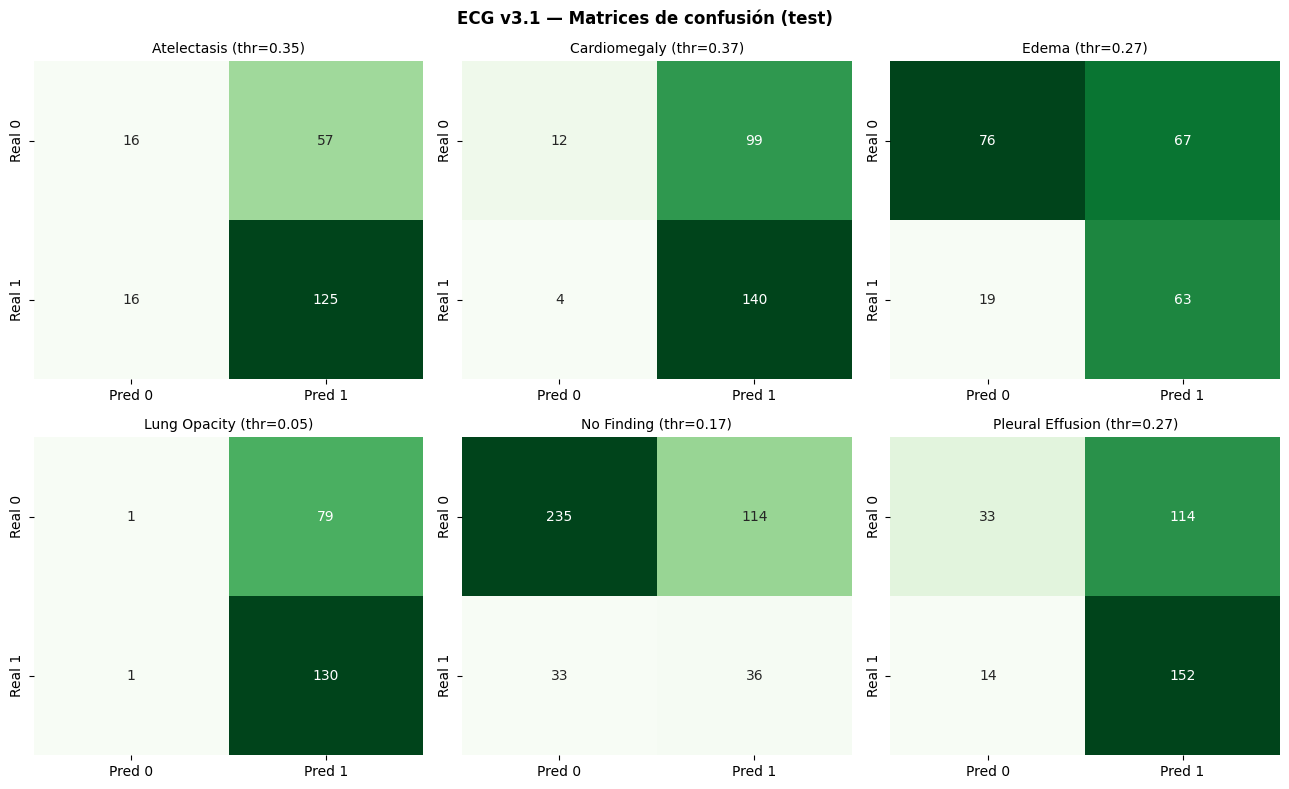

Matrices de confusión guardadas.


In [16]:
# CELDA 15 · MATRICES DE CONFUSIÓN
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("ECG v3.1 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",cbar=False,ax=ax,
                xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_matrices_v3_1.png",dpi=150,bbox_inches="tight"); plt.show()
print("Matrices de confusión guardadas.")


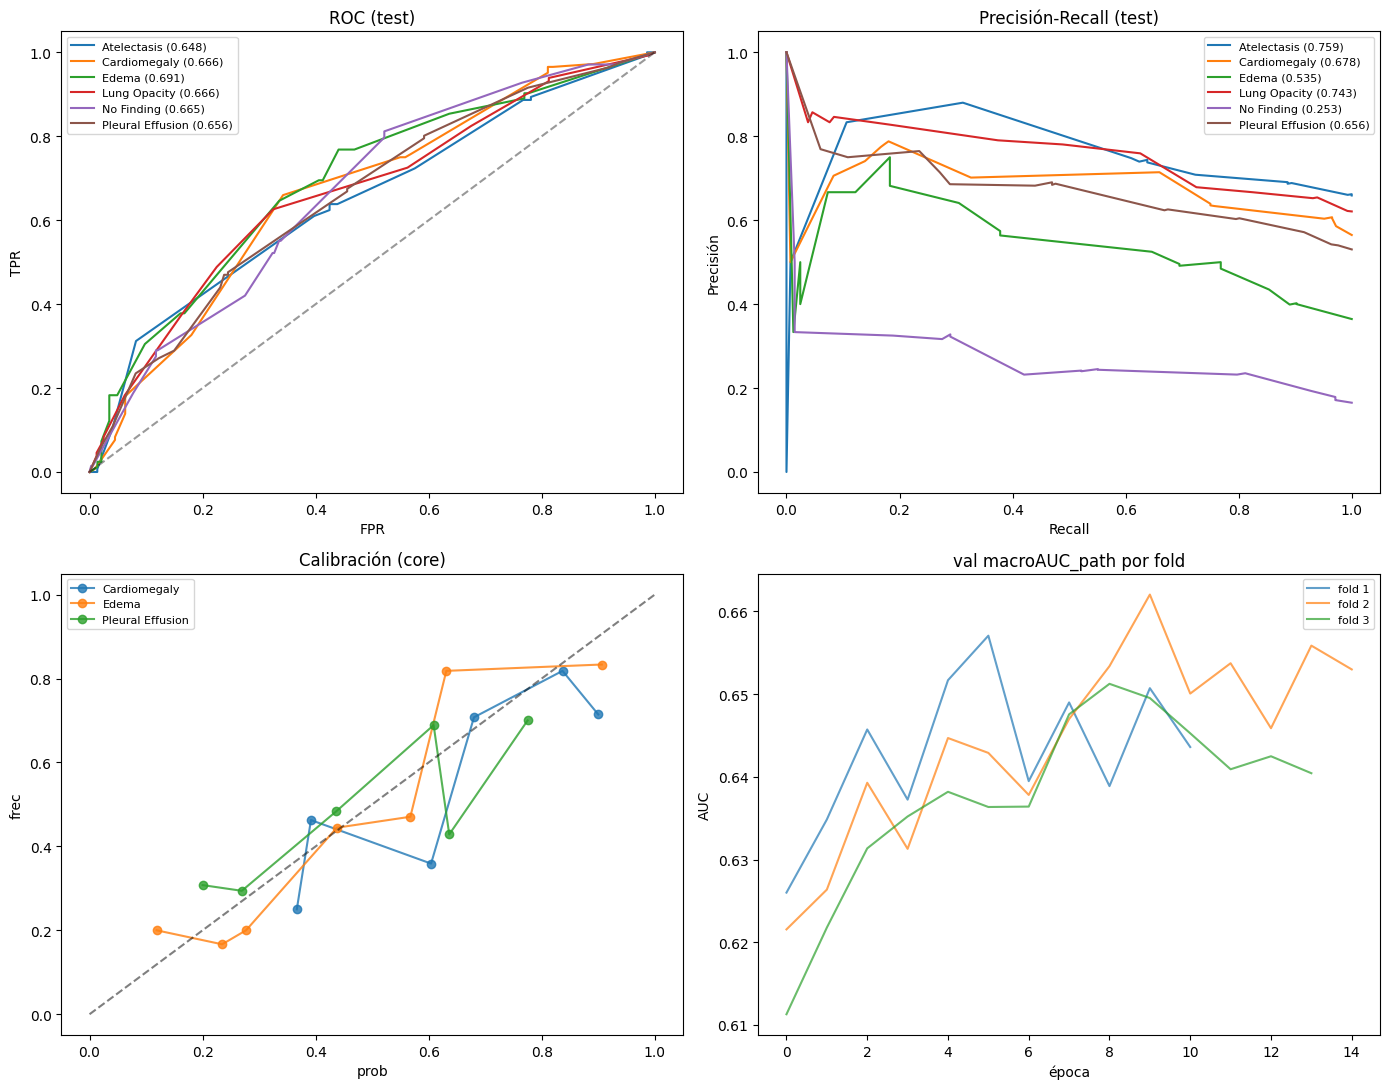

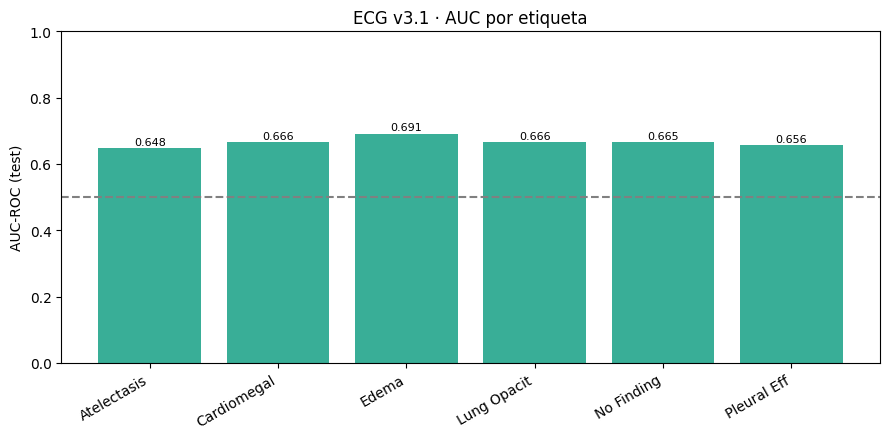

Figuras guardadas en C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_ecg_resnet1d_v2_uignore\figuras


In [17]:
# CELDA 16 · CURVAS ROC / PR / CALIBRACIÓN / ENTRENAMIENTO + AUC
fig,axes=plt.subplots(2,2,figsize=(14,11))
ax=axes[0,0]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); ax.plot(fpr,tpr,label=f"{l} ({M[l]['AUC']:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4); ax.set_title("ROC (test)"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
ax=axes[0,1]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    pr,rc,_=precision_recall_curve(yt,yp); ax.plot(rc,pr,label=f"{l} ({M[l]['AP']:.3f})")
ax.set_title("Precisión-Recall (test)"); ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.legend(fontsize=8)
ax=axes[1,0]
for l in CORE_LABELS:
    j=LABELS.index(l); s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    bins=np.linspace(0,1,9); idx=np.digitize(yp,bins)-1; xs,ys=[],[]
    for b in range(len(bins)-1):
        mb=idx==b
        if mb.sum()>5: xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs,ys,"o-",label=l,alpha=0.8)
ax.plot([0,1],[0,1],"k--",alpha=0.5); ax.set_title("Calibración (core)"); ax.set_xlabel("prob"); ax.set_ylabel("frec"); ax.legend(fontsize=8)
ax=axes[1,1]
for k,h in enumerate(histories): ax.plot(h["val_auc"],alpha=0.7,label=f"fold {k+1}")
ax.set_title("val macroAUC_path por fold"); ax.set_xlabel("época"); ax.set_ylabel("AUC"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"curvas_v3_1.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],
       color=["#c0392b" if (np.isnan(a) or a<0.55) else "#16a085" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("ECG v3.1 · AUC por etiqueta")
for i,a in enumerate(aucs):
    if not np.isnan(a): ax.text(i,a+0.01,f"{a:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"auc_por_etiqueta_v3_1.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figuras guardadas en", FIG_DIR)


In [ ]:
# CELDA 17 · EQUIDAD Y ROBUSTEZ POR SUBGRUPO -> ya cubierto por B8 en la CELDA 14
# La funcion stratified_report (kit clinico) calcula el macro AUC-PR por sexo, etnia, tipo de ingreso
# y PROYECCION radiografica, y exporta estratificacion_subgrupos.csv.
# ORIGEN EDA: §2/§9 "evaluar equidad por sexo y etnia" · ANEXO CXR "monitorizar el efecto de cxr_view".
# INTERPRETACION FUTURA (-> recuadro naranja de la doc post-resultados): subgrupos con n<60 pueden
# diferir por PURO RUIDO; no afirmar inequidad sin intervalo de confianza.
print("Equidad por subgrupo: ver estratificacion_subgrupos.csv (calculado en la CELDA 14, bloque B8).")
try:
    print(strat.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
except NameError:
    print("   (ejecuta antes la CELDA 14)")



---
## ✅ Conclusión — Módulo ECG v2 (óptimo)

**ResNet-1D base 48** sobre señal de 1250 puntos, con aumento rico, **Optuna optimizando AUC-PR**,
K-fold con **ensemble por bagging**, pérdida **BCE enmascarada** con `pos_weight` por etiqueta,
calibración isotónica en VAL y **OOF sin fuga** para el stacking multimodal.

Adopta el **etiquetado FINAL**, la métrica **AUC-PR con IC bootstrap** y el **kit clínico B1, B2, B3,
B4, B6 y B8** (B5 y B7 no aplican a esta modalidad).

### 📌 Para la documentación posterior (recuadros naranjas a redactar con los resultados)
- **¿Alguna AP supera su prevalencia?** Es la prueba de señal real. El EDA anticipaba que el ECG
  aporta poco en solitario; su valor es como **modalidad complementaria** en la fusión.
- **¿Mejora v2 sobre v1?** Comparar con la **misma métrica y el mismo etiquetado**, y mirar si los
  **IC se solapan**: si lo hacen, la mejora **no es concluyente** y conviene decirlo.
- **Puntos de operación**: contrastar los falsos negativos del punto de cribado con los falsos
  positivos del de confirmación; indicar si alguno es clínicamente asumible.
- **Calibración**: ¿baja el Brier tras la isotónica? Recordar que hay que **recalibrar tras la fusión**.
- **Consistencia**: la correlación entre P(*Sin hallazgo*) y max P(patología) debe ser **negativa**.
- **Equidad**: subgrupos con n<60 ⇒ posible **ruido**, no inequidad. No concluir sin IC.
- **Proyección AP/PA**: comentar si el rendimiento difiere entre proyecciones (sesgo de espectro).

